# Visualization Notebook for the Vietnam Macro-Growth Project

This notebook turns the empirical results already generated in the repository into a cleaner and more interpretable visualization layer for the final report.

**What is included**
- Macro time-series plots for GDP, inflation, and real interest rate
- Correlation heatmap and bivariate relationship checks
- Stationarity summary with ACF/PACF plots
- SARIMAX forecast plot with confidence intervals
- VAR impulse response functions (IRFs)
- Annual OLS/HAC coefficient chart with 95% confidence intervals
- An extra model-comparison chart using the reported ARIMA vs SARIMAX metrics

The notebook is written in English and structured as alternating Markdown and Code blocks for readability.


## How to use this notebook

1. Place the notebook in the repository root, or in the same folder as `secondary_data_annual.csv` and `secondary_data_processed.csv`.
2. Run the notebook from top to bottom.
3. The notebook will first try to load local CSV files. If they are not found, it will fall back to the raw GitHub URLs of your repository.

**Important note on frequency**
- The **annual** dataset is used for the structural regression and long-run macro visualization.
- The **processed quarterly** dataset is used for ACF/PACF, SARIMAX forecasting, and VAR/IRF analysis.

**Interpretation caution**
Some quarterly macro variables in the processed file are repository-processed series rather than direct official quarterly releases. The short-run VAR and IRF outputs should therefore be interpreted as **approximate dynamic evidence**, not as a perfect substitute for official quarterly macro data.


In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.api import VAR
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tools.sm_exceptions import InterpolationWarning

warnings.filterwarnings("ignore", category=InterpolationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


def safe_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def locate_project_root():
    candidates = [Path.cwd(), *Path.cwd().parents]

    extra_paths = [
        Path("/mnt/data"),
        Path.home(),
    ]
    for extra in extra_paths:
        if extra.exists():
            candidates.append(extra)

    seen = set()
    unique_candidates = []
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate not in seen:
            seen.add(candidate)
            unique_candidates.append(candidate)

    for candidate in unique_candidates:
        if (candidate / "secondary_data_annual.csv").exists() and (candidate / "secondary_data_processed.csv").exists():
            return candidate
    return None


GITHUB_RAW = "https://raw.githubusercontent.com/lequoctran181/Data_Science_Midterm_Project/main"
PROJECT_ROOT = locate_project_root()


def read_project_csv(filename):
    if PROJECT_ROOT is not None and (PROJECT_ROOT / filename).exists():
        return pd.read_csv(PROJECT_ROOT / filename)
    return pd.read_csv(f"{GITHUB_RAW}/{filename}")


In [3]:
annual_raw = read_project_csv("secondary_data_annual.csv")
quarterly_raw = read_project_csv("secondary_data_processed.csv")

annual = annual_raw.rename(
    columns={
        "Year": "year",
        "GDP_Raw": "gdp_raw",
        "Inflation": "inflation",
        "Interest_Rate": "interest_rate",
        "FDI_pct_GDP": "fdi_pct_gdp",
        "Investment_pct_GDP": "investment_pct_gdp",
        "Export_pct_GDP": "export_pct_gdp",
        "Unemployment_Rate": "unemployment_rate",
        "Gov_Spending_pct_GDP": "gov_spending_pct_gdp",
        "GDP_Growth": "gdp_growth",
    }
).copy()

annual["year_end"] = pd.to_datetime(annual["year"].astype("Int64").astype(str) + "-12-31", errors="coerce")
annual = annual.set_index("year_end").sort_index().asfreq("YE-DEC")

quarterly = quarterly_raw.rename(
    columns={
        "Unnamed: 0": "quarter_start",
        "GDP_Raw": "gdp_raw",
        "Inflation": "inflation",
        "Interest_Rate": "interest_rate",
        "FDI_pct_GDP": "fdi_pct_gdp",
        "Investment_pct_GDP": "investment_pct_gdp",
        "Export_pct_GDP": "export_pct_gdp",
        "Unemployment_Rate": "unemployment_rate",
        "Gov_Spending_pct_GDP": "gov_spending_pct_gdp",
        "GDP_Growth": "gdp_growth",
        "log_GDP": "log_gdp",
        "GDP_qoq_pct_recalc": "gdp_qoq_pct_recalc",
        "GDP_yoy_pct_recalc": "gdp_yoy_pct_recalc",
        "Inflation_lag1": "inflation_lag1",
        "Inflation_lag2": "inflation_lag2",
        "Interest_Rate_lag1": "interest_rate_lag1",
        "Interest_Rate_lag2": "interest_rate_lag2",
        "log_GDP_diff1": "log_gdp_diff1",
        "log_GDP_diff4": "log_gdp_diff4",
    }
).copy()

quarterly["quarter_start"] = pd.to_datetime(quarterly["quarter_start"])
quarterly["quarter_end"] = quarterly["quarter_start"] + pd.offsets.QuarterEnd(0)
quarterly = quarterly.set_index("quarter_end").sort_index().asfreq("QE-DEC")

summary = pd.DataFrame(
    {
        "dataset": ["annual", "quarterly_processed"],
        "rows": [len(annual), len(quarterly)],
        "columns": [annual.shape[1], quarterly.shape[1]],
        "date_start": [annual.index.min().date(), quarterly.index.min().date()],
        "date_end": [annual.index.max().date(), quarterly.index.max().date()],
        "source": [
            str(PROJECT_ROOT / "secondary_data_annual.csv") if PROJECT_ROOT else f"{GITHUB_RAW}/secondary_data_annual.csv",
            str(PROJECT_ROOT / "secondary_data_processed.csv") if PROJECT_ROOT else f"{GITHUB_RAW}/secondary_data_processed.csv",
        ],
    }
)

display(summary)


,dataset,rows,columns,date_start,date_end,source
0,annual,31,10,1995-12-31,2025-12-31,/Users/TranAnh/Documents/Data_file_NCKH/second...
1,quarterly_processed,120,26,1995-06-30,2025-03-31,/Users/TranAnh/Documents/Data_file_NCKH/second...


## Data overview

Before plotting the empirical outputs, it is useful to check the effective sample and missing-value pattern.  
The structural regression uses the annual macro sample, while the forecasting and VAR blocks use the processed quarterly sample.


In [4]:
missing_table = pd.concat(
    [
        annual.isna().sum().rename("annual_missing"),
        quarterly.isna().sum().rename("quarterly_missing"),
    ],
    axis=1,
).fillna(0).astype(int)

sample_overview = pd.DataFrame(
    {
        "analysis_block": [
            "Annual structural regression",
            "Quarterly forecasting / ACF-PACF / VAR",
        ],
        "sample_window": [
            "1996-2023 after dropping missing values",
            "1995Q3-2025Q1 after dropping missing values",
        ],
        "main_variables": [
            "gdp_growth, inflation, interest_rate, fdi, investment, exports, unemployment, government spending",
            "gdp_qoq_pct_recalc, gdp_growth, inflation, interest_rate",
        ],
    }
)

display(sample_overview)
display(missing_table)


,analysis_block,sample_window,main_variables
0,Annual structural regression,1996-2023 after dropping missing values,"gdp_growth, inflation, interest_rate, fdi, inv..."
1,Quarterly forecasting / ACF-PACF / VAR,1995Q3-2025Q1 after dropping missing values,"gdp_qoq_pct_recalc, gdp_growth, inflation, int..."


,annual_missing,quarterly_missing
year,0,0
gdp_raw,1,0
inflation,2,0
interest_rate,3,0
fdi_pct_gdp,1,0
investment_pct_gdp,1,0
export_pct_gdp,1,0
unemployment_rate,0,0
gov_spending_pct_gdp,1,0
gdp_growth,1,0


## 1. Macro time-series plots

This first visualization block gives a long-run view of the three headline variables requested in the proposal:

- GDP
- inflation (CPI-based annual inflation rate)
- real interest rate

The purpose is descriptive: to show the evolution of Vietnam's macro environment before moving to formal modeling.


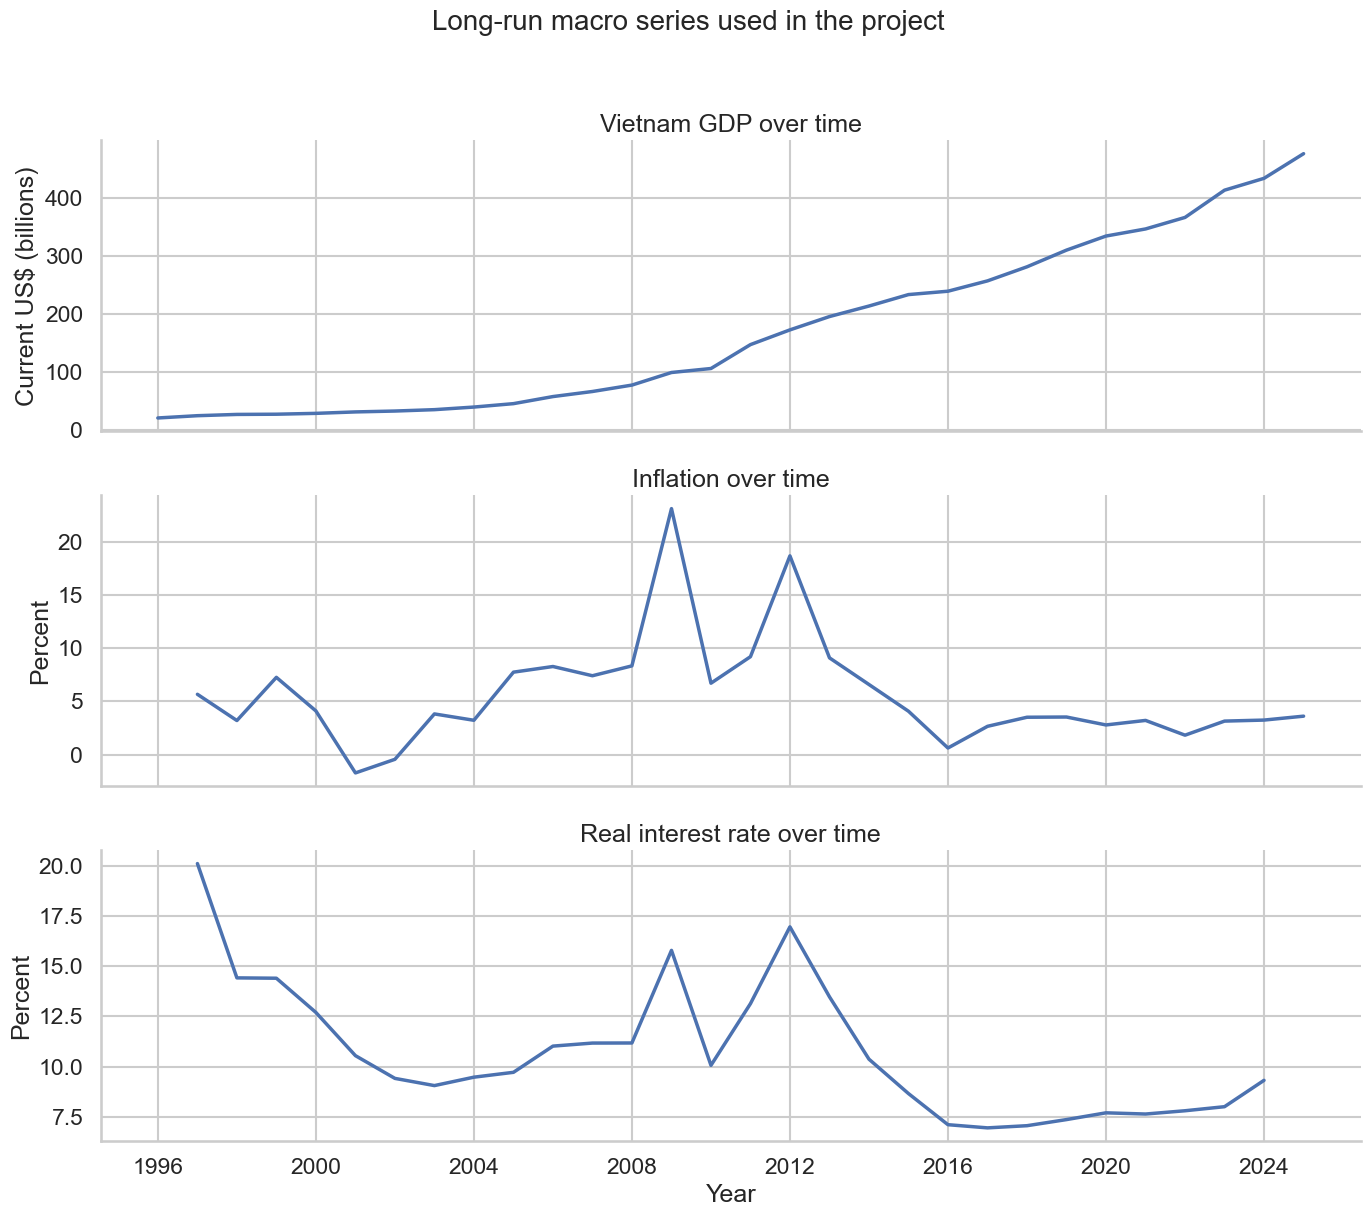

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

axes[0].plot(annual.index, annual["gdp_raw"], linewidth=2.5)
axes[0].set_title("Vietnam GDP over time")
axes[0].set_ylabel("Current US$ (billions)")

axes[1].plot(annual.index, annual["inflation"], linewidth=2.5)
axes[1].set_title("Inflation over time")
axes[1].set_ylabel("Percent")

axes[2].plot(annual.index, annual["interest_rate"], linewidth=2.5)
axes[2].set_title("Real interest rate over time")
axes[2].set_ylabel("Percent")
axes[2].set_xlabel("Year")

fig.suptitle("Long-run macro series used in the project", y=1.02, fontsize=20)
plt.tight_layout()
plt.show()


## 2. Correlation structure and simple bivariate views

The heatmap gives a compact view of how the structural variables move together in the annual sample.  
The two bivariate plots help connect the heatmap to the economic question: how GDP growth co-moves with inflation and the real interest rate.


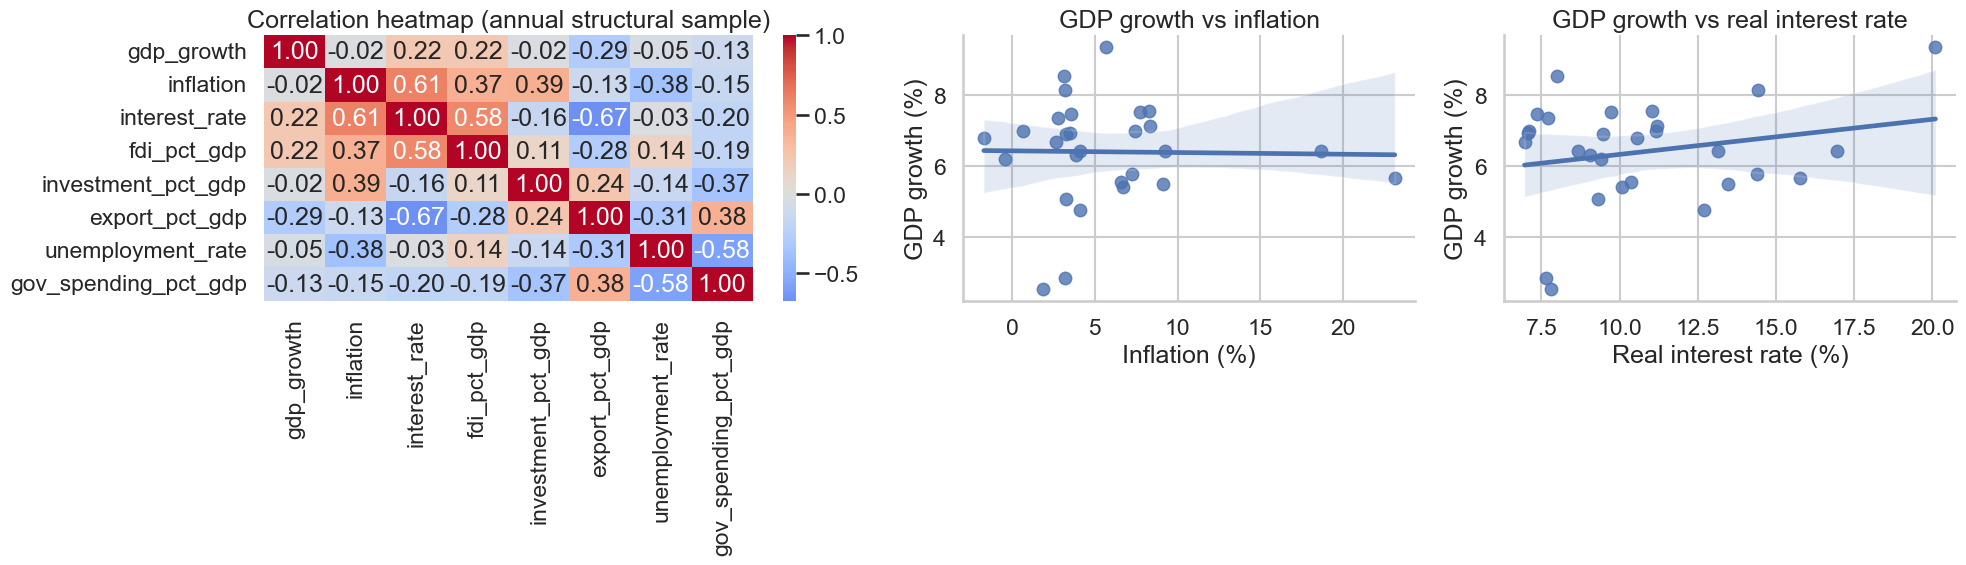

,correlation_with_gdp_growth
gdp_growth,1.000000
interest_rate,0.223262
fdi_pct_gdp,0.222740
inflation,-0.016737
investment_pct_gdp,-0.022222
unemployment_rate,-0.050614
gov_spending_pct_gdp,-0.128750
export_pct_gdp,-0.292923


In [6]:
annual_model = annual.loc["1996-12-31":"2023-12-31", [
    "gdp_growth",
    "inflation",
    "interest_rate",
    "fdi_pct_gdp",
    "investment_pct_gdp",
    "export_pct_gdp",
    "unemployment_rate",
    "gov_spending_pct_gdp",
]].dropna()

corr = annual_model.corr()

fig, axes = plt.subplots(1, 3, figsize=(20, 6), gridspec_kw={"width_ratios": [1.35, 1, 1]})

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0])
axes[0].set_title("Correlation heatmap (annual structural sample)")

sns.regplot(data=annual_model, x="inflation", y="gdp_growth", ax=axes[1], scatter_kws={"alpha": 0.8})
axes[1].set_title("GDP growth vs inflation")
axes[1].set_xlabel("Inflation (%)")
axes[1].set_ylabel("GDP growth (%)")

sns.regplot(data=annual_model, x="interest_rate", y="gdp_growth", ax=axes[2], scatter_kws={"alpha": 0.8})
axes[2].set_title("GDP growth vs real interest rate")
axes[2].set_xlabel("Real interest rate (%)")
axes[2].set_ylabel("GDP growth (%)")

plt.tight_layout()
plt.show()

display(
    annual_model.corr()[["gdp_growth"]]
    .rename(columns={"gdp_growth": "correlation_with_gdp_growth"})
    .sort_values("correlation_with_gdp_growth", ascending=False)
)


## 3. Stationarity summary, ACF, and PACF

The ACF/PACF plots are included because they are part of the time-series modeling logic in the proposal.  
Two quarterly targets are shown:

- `gdp_qoq_pct_recalc`: the short-run GDP growth series used in the final SARIMAX forecasting block
- `gdp_growth`: the repository's processed GDP growth series, included to mirror the reported PACF snapshot

The table above the plots gives ADF and KPSS results to help assess stationarity.


,series,adf_stat,adf_pvalue,kpss_stat,kpss_pvalue
0,Quarterly log GDP,-0.6910,0.8491,1.8004,0.01
1,Quarterly Δlog GDP,-2.1804,0.2135,0.3327,0.10
2,Quarterly GDP growth (reported),-3.8251,0.0027,0.2285,0.10
3,Quarterly GDP q/q growth (recalculated),-2.1844,0.2120,0.3330,0.10
4,Quarterly inflation,-2.0890,0.2489,0.2809,0.10
5,Quarterly interest rate,-2.2958,0.1733,0.7667,0.01


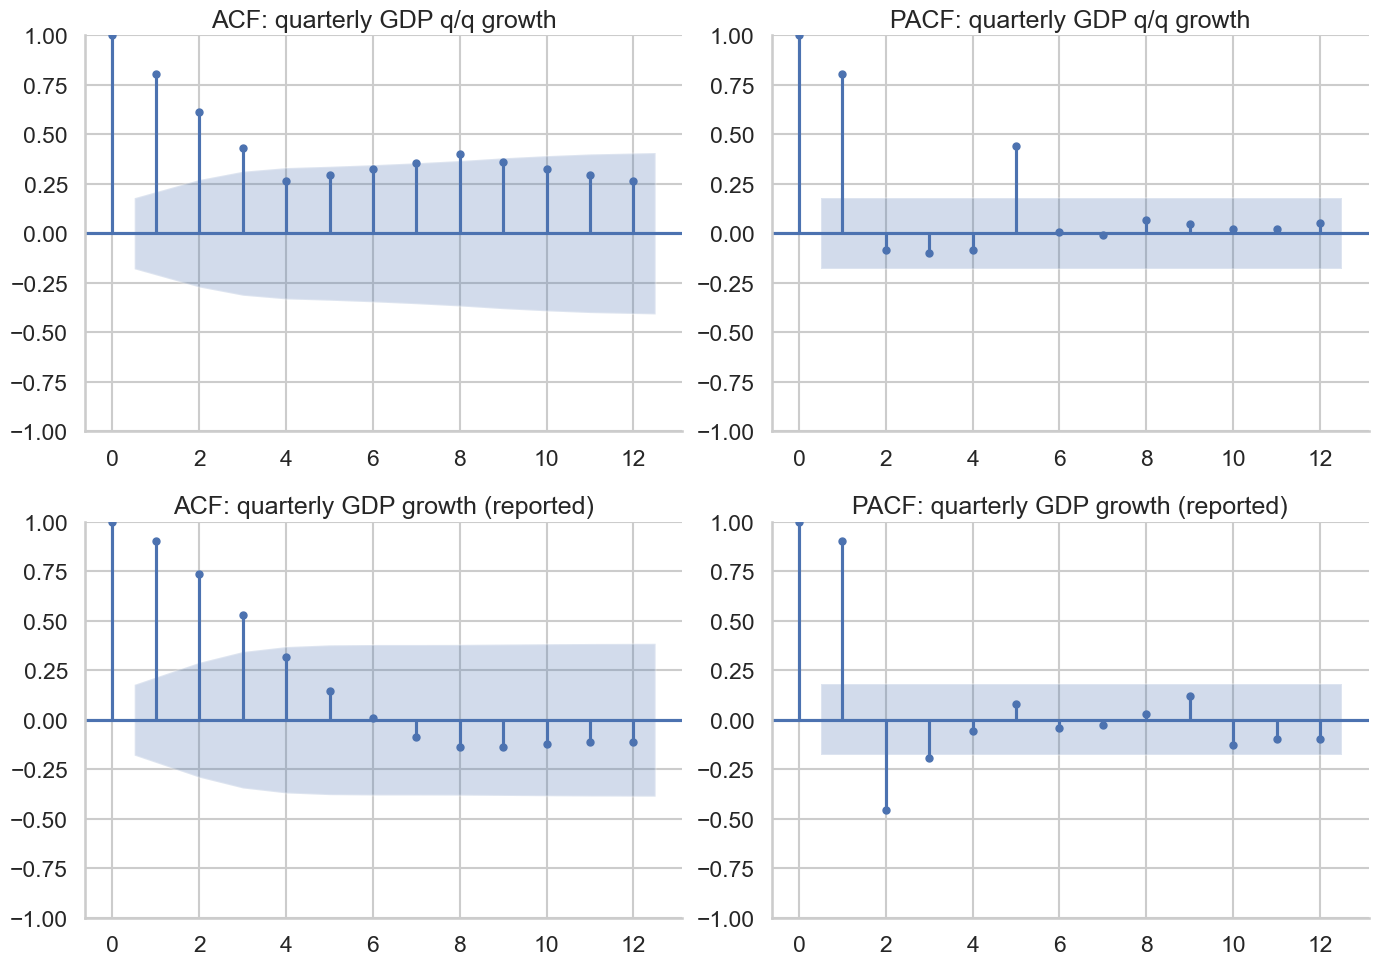

In [7]:
def stationarity_summary(series):
    s = pd.Series(series).dropna()
    adf_stat, adf_p, *_ = adfuller(s, autolag="AIC")
    try:
        kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")
    except Exception:
        kpss_stat, kpss_p = np.nan, np.nan
    return adf_stat, adf_p, kpss_stat, kpss_p


stationarity_rows = []
series_map = {
    "Quarterly log GDP": quarterly["log_gdp"],
    "Quarterly Δlog GDP": quarterly["log_gdp_diff1"],
    "Quarterly GDP growth (reported)": quarterly["gdp_growth"],
    "Quarterly GDP q/q growth (recalculated)": quarterly["gdp_qoq_pct_recalc"],
    "Quarterly inflation": quarterly["inflation"],
    "Quarterly interest rate": quarterly["interest_rate"],
}

for name, series in series_map.items():
    adf_stat, adf_p, kpss_stat, kpss_p = stationarity_summary(series)
    stationarity_rows.append(
        {
            "series": name,
            "adf_stat": adf_stat,
            "adf_pvalue": adf_p,
            "kpss_stat": kpss_stat,
            "kpss_pvalue": kpss_p,
        }
    )

stationarity_df = pd.DataFrame(stationarity_rows)
display(stationarity_df.round(4))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_acf(quarterly["gdp_qoq_pct_recalc"].dropna(), lags=12, ax=axes[0, 0])
axes[0, 0].set_title("ACF: quarterly GDP q/q growth")

plot_pacf(quarterly["gdp_qoq_pct_recalc"].dropna(), lags=12, ax=axes[0, 1], method="ywm")
axes[0, 1].set_title("PACF: quarterly GDP q/q growth")

plot_acf(quarterly["gdp_growth"].dropna(), lags=12, ax=axes[1, 0])
axes[1, 0].set_title("ACF: quarterly GDP growth (reported)")

plot_pacf(quarterly["gdp_growth"].dropna(), lags=12, ax=axes[1, 1], method="ywm")
axes[1, 1].set_title("PACF: quarterly GDP growth (reported)")

plt.tight_layout()
plt.show()


## 4. Forecast visualization with the reported SARIMAX specification

The reported final macro forecasting specification in the modeling report is:

- **Target:** `gdp_qoq_pct_recalc`
- **Model:** `SARIMAX(0, 0, 3)`
- **Exogenous variables:** inflation and real interest rate
- **Time split for visualization:** train through **2022Q4**, forecast **2023Q1-2024Q4**

The next cell reproduces that forecast visualization and reports the resulting test metrics.


,metric,value
0,RMSE,0.2118
1,MAE,0.1626
2,MAPE,8.0705


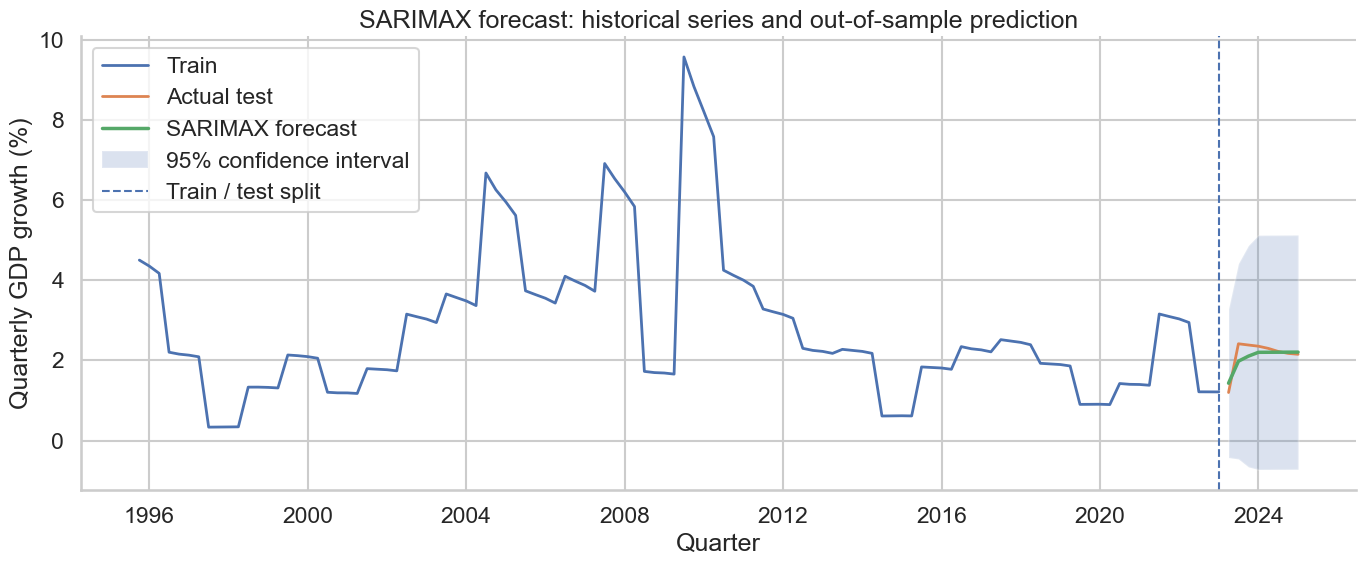

,term,coef,std_err,p_value,ci_low,ci_high
0,intercept,2.0264,2.0257,0.3171,-1.9439,5.9968
1,inflation,0.2360,0.0887,0.0078,0.0622,0.4099
2,interest_rate,-0.0634,0.2056,0.7578,-0.4664,0.3396
3,ma.L1,0.8530,0.2091,0.0000,0.4430,1.2629
4,ma.L2,0.6997,0.1804,0.0001,0.3461,1.0532
5,ma.L3,0.5158,0.0944,0.0000,0.3308,0.7008
6,sigma2,0.8309,0.0536,0.0000,0.7258,0.9361


In [8]:
forecast_sample = quarterly[["gdp_qoq_pct_recalc", "inflation", "interest_rate"]].dropna()
train = forecast_sample.loc[: "2022-12-31"].copy()
test = forecast_sample.loc["2023-03-31":"2024-12-31"].copy()

sarimax_train = SARIMAX(
    train["gdp_qoq_pct_recalc"],
    exog=train[["inflation", "interest_rate"]],
    order=(0, 0, 3),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

forecast_res = sarimax_train.get_forecast(
    steps=len(test),
    exog=test[["inflation", "interest_rate"]],
)
forecast_mean = forecast_res.predicted_mean
forecast_ci = forecast_res.conf_int()

forecast_metrics = pd.DataFrame(
    {
        "metric": ["RMSE", "MAE", "MAPE"],
        "value": [
            np.sqrt(np.mean((test["gdp_qoq_pct_recalc"] - forecast_mean) ** 2)),
            np.mean(np.abs(test["gdp_qoq_pct_recalc"] - forecast_mean)),
            safe_mape(test["gdp_qoq_pct_recalc"], forecast_mean),
        ],
    }
)
display(forecast_metrics.round(4))

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train.index, train["gdp_qoq_pct_recalc"], label="Train", linewidth=2)
ax.plot(test.index, test["gdp_qoq_pct_recalc"], label="Actual test", linewidth=2)
ax.plot(forecast_mean.index, forecast_mean, label="SARIMAX forecast", linewidth=2.5)
ax.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.2,
    label="95% confidence interval",
)
ax.axvline(pd.Timestamp("2022-12-31"), linestyle="--", linewidth=1.5, label="Train / test split")
ax.set_title("SARIMAX forecast: historical series and out-of-sample prediction")
ax.set_ylabel("Quarterly GDP growth (%)")
ax.set_xlabel("Quarter")
ax.legend()
plt.tight_layout()
plt.show()

full_sarimax = SARIMAX(
    forecast_sample["gdp_qoq_pct_recalc"],
    exog=forecast_sample[["inflation", "interest_rate"]],
    order=(0, 0, 3),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

sarimax_coef = pd.DataFrame(
    {
        "term": full_sarimax.params.index,
        "coef": full_sarimax.params.values,
        "std_err": full_sarimax.bse.values,
        "p_value": full_sarimax.pvalues.values,
    }
)
sarimax_coef["ci_low"] = sarimax_coef["coef"] - 1.96 * sarimax_coef["std_err"]
sarimax_coef["ci_high"] = sarimax_coef["coef"] + 1.96 * sarimax_coef["std_err"]

display(sarimax_coef.round(4))


## 5. Residual diagnostics for the final SARIMAX

A forecast plot is useful, but diagnostics are also important.  
The next cell fits the final SARIMAX model on the full available quarterly sample and then visualizes residual behavior.  
This helps assess whether the remaining errors are close to white noise.


,lb_stat,lb_pvalue
4,5.5823,0.2326
8,14.2028,0.0766


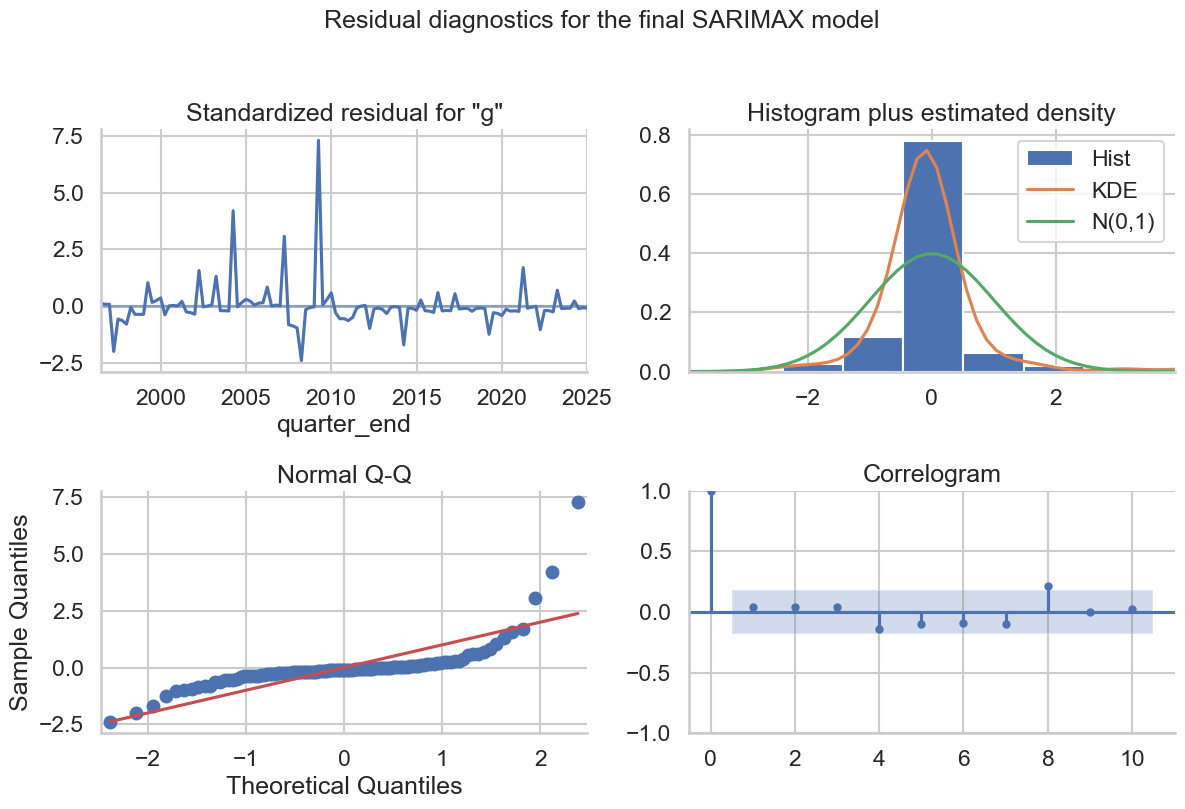

In [9]:
ljung_box = acorr_ljungbox(full_sarimax.resid, lags=[4, 8], return_df=True)
display(ljung_box.round(4))

diag_fig = full_sarimax.plot_diagnostics(figsize=(12, 8))
diag_fig.suptitle("Residual diagnostics for the final SARIMAX model", y=1.02, fontsize=18)
plt.tight_layout()
plt.show()


## 6. VAR impulse response functions (IRFs)

To visualize short-run dynamic effects, this block estimates a **VAR(2)** system on:

- `gdp_growth`
- `inflation`
- `interest_rate`

The focus is the response of GDP growth to shocks in inflation and the real interest rate.  
This aligns with the proposal's suggestion to use IRFs when a VAR framework is included.


,item,value
0,Selected lag (imposed),2
1,Stable VAR,True


,hypothesis,p_value
0,inflation -> gdp_growth,0.4001
1,interest_rate -> gdp_growth,0.3321
2,inflation + interest_rate -> gdp_growth,0.6475


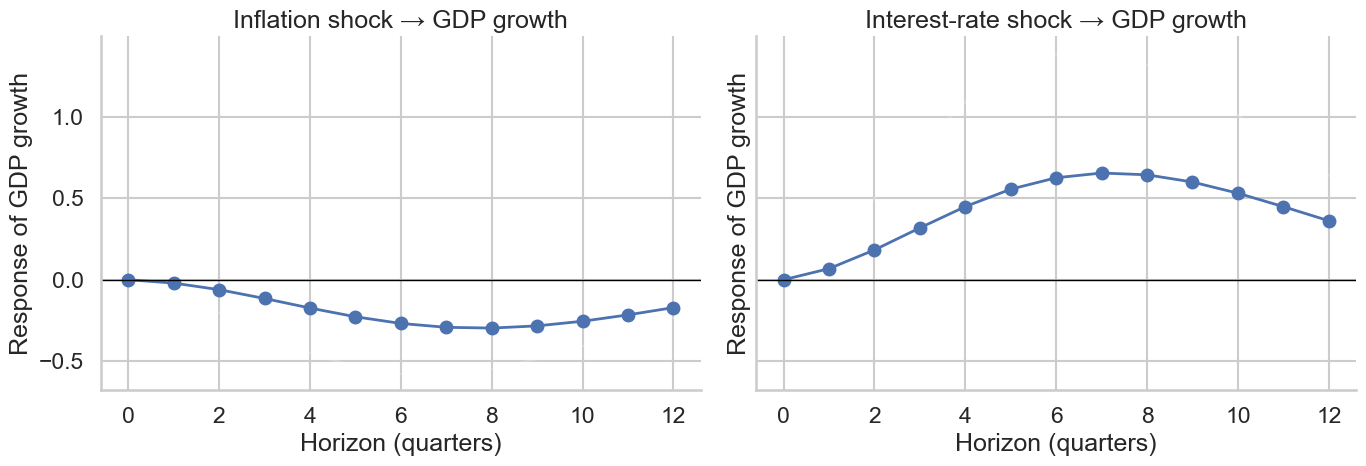

In [10]:
var_df = quarterly[["gdp_growth", "inflation", "interest_rate"]].dropna()

var_result = VAR(var_df).fit(2)

var_summary = pd.DataFrame(
    {
        "item": ["Selected lag (imposed)", "Stable VAR"],
        "value": [2, var_result.is_stable(verbose=False)],
    }
)

granger_df = pd.DataFrame(
    {
        "hypothesis": [
            "inflation -> gdp_growth",
            "interest_rate -> gdp_growth",
            "inflation + interest_rate -> gdp_growth",
        ],
        "p_value": [
            var_result.test_causality("gdp_growth", ["inflation"], kind="f").pvalue,
            var_result.test_causality("gdp_growth", ["interest_rate"], kind="f").pvalue,
            var_result.test_causality("gdp_growth", ["inflation", "interest_rate"], kind="f").pvalue,
        ],
    }
)

display(var_summary)
display(granger_df.round(4))

irf = var_result.irf(12)
lower, upper = irf.errband_mc(orth=False, repl=300, signif=0.05, seed=42)

names = var_result.names
response_idx = names.index("gdp_growth")
inflation_idx = names.index("inflation")
rate_idx = names.index("interest_rate")
horizon = np.arange(irf.irfs.shape[0])

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, impulse_idx, title in zip(
    axes,
    [inflation_idx, rate_idx],
    ["Inflation shock → GDP growth", "Interest-rate shock → GDP growth"],
):
    response = irf.irfs[:, response_idx, impulse_idx]
    lower_band = lower[:, response_idx, impulse_idx]
    upper_band = upper[:, response_idx, impulse_idx]

    ax.plot(horizon, response, marker="o", linewidth=2)
    ax.fill_between(horizon, lower_band, upper_band, alpha=0.2)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Horizon (quarters)")
    ax.set_ylabel("Response of GDP growth")

plt.tight_layout()
plt.show()


## 7. Annual structural coefficients (OLS/HAC)

The next block estimates the annual structural model and visualizes the regression coefficients with **95% confidence intervals**.

This is the most direct answer to the question:  
**Which macro factors appear to be positively or negatively associated with Vietnam's GDP growth in the annual regression?**


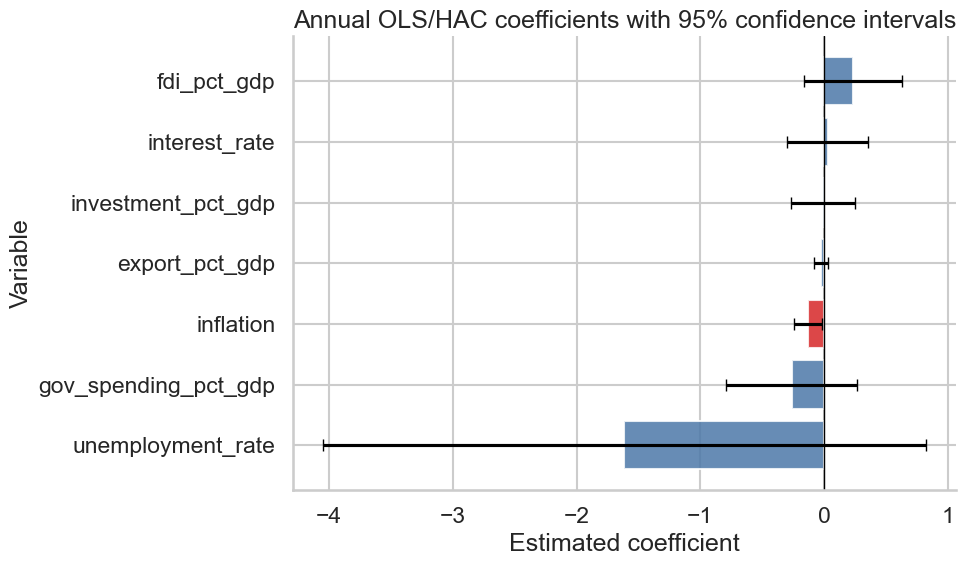

,variable,coef,std_err,p_value,ci_low,ci_high
0,const,12.6488,9.4160,0.1792,-5.8065,31.1041
1,inflation,-0.1266,0.0581,0.0294,-0.2406,-0.0127
2,interest_rate,0.0294,0.1670,0.8601,-0.2979,0.3568
3,fdi_pct_gdp,0.2332,0.2011,0.2460,-0.1608,0.6273
4,investment_pct_gdp,-0.0060,0.1312,0.9637,-0.2632,0.2512
5,export_pct_gdp,-0.0253,0.0291,0.3854,-0.0823,0.0318
6,unemployment_rate,-1.6131,1.2435,0.1946,-4.0504,0.8242
7,gov_spending_pct_gdp,-0.2615,0.2692,0.3314,-0.7892,0.2662


,variable,VIF
1,inflation,3.907
2,interest_rate,7.218
3,fdi_pct_gdp,1.990
4,investment_pct_gdp,2.757
5,export_pct_gdp,3.073
6,unemployment_rate,2.883
7,gov_spending_pct_gdp,3.043


In [11]:
predictors = [
    "inflation",
    "interest_rate",
    "fdi_pct_gdp",
    "investment_pct_gdp",
    "export_pct_gdp",
    "unemployment_rate",
    "gov_spending_pct_gdp",
]

X = sm.add_constant(annual_model[predictors])
y = annual_model["gdp_growth"]

ols_hac = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 1})

coef_df = pd.DataFrame(
    {
        "variable": ols_hac.params.index,
        "coef": ols_hac.params.values,
        "std_err": ols_hac.bse.values,
        "p_value": ols_hac.pvalues.values,
    }
)
coef_df["ci_low"] = coef_df["coef"] - 1.96 * coef_df["std_err"]
coef_df["ci_high"] = coef_df["coef"] + 1.96 * coef_df["std_err"]

coef_plot = coef_df.query("variable != 'const'").copy().sort_values("coef")
coef_plot["significant_5pct"] = coef_plot["p_value"] < 0.05

colors = np.where(coef_plot["significant_5pct"], "#d62728", "#4c78a8")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(coef_plot["variable"], coef_plot["coef"], color=colors, alpha=0.85)
ax.errorbar(
    coef_plot["coef"],
    coef_plot["variable"],
    xerr=1.96 * coef_plot["std_err"],
    fmt="none",
    ecolor="black",
    capsize=4,
)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Annual OLS/HAC coefficients with 95% confidence intervals")
ax.set_xlabel("Estimated coefficient")
ax.set_ylabel("Variable")
plt.tight_layout()
plt.show()

X_vif = sm.add_constant(annual_model[predictors])
vif_df = pd.DataFrame(
    {
        "variable": X_vif.columns,
        "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
    }
).query("variable != 'const'")

display(coef_df.round(4))
display(vif_df.round(3))


## 8. Extra chart: reported ARIMA vs SARIMAX model comparison

The proposal asks for forecast visualization.  
A useful extra chart is to compare the **reported** out-of-sample metrics for ARIMA and SARIMAX across the three forecast targets listed in the modeling report.

This section uses the values already reported in the repository output so that the ranking is visible at a glance.


,target,model,order,RMSE,MAE,MAPE,target_label
0,log_gdp,ARIMA,"(1, 1, 0)",0.0080,0.0074,0.12,log GDP
1,log_gdp,SARIMAX,"(0, 2, 0)",0.0463,0.0392,0.63,log GDP
2,gdp_growth,ARIMA,"(2, 0, 0)",1.8303,1.6438,22.66,GDP growth
3,gdp_growth,SARIMAX,"(2, 0, 0)",1.5761,1.4318,19.86,GDP growth
4,gdp_qoq_pct_recalc,ARIMA,"(1, 0, 0)",0.3477,0.3015,14.64,GDP q/q growth
5,gdp_qoq_pct_recalc,SARIMAX,"(0, 0, 3)",0.2232,0.1933,9.66,GDP q/q growth


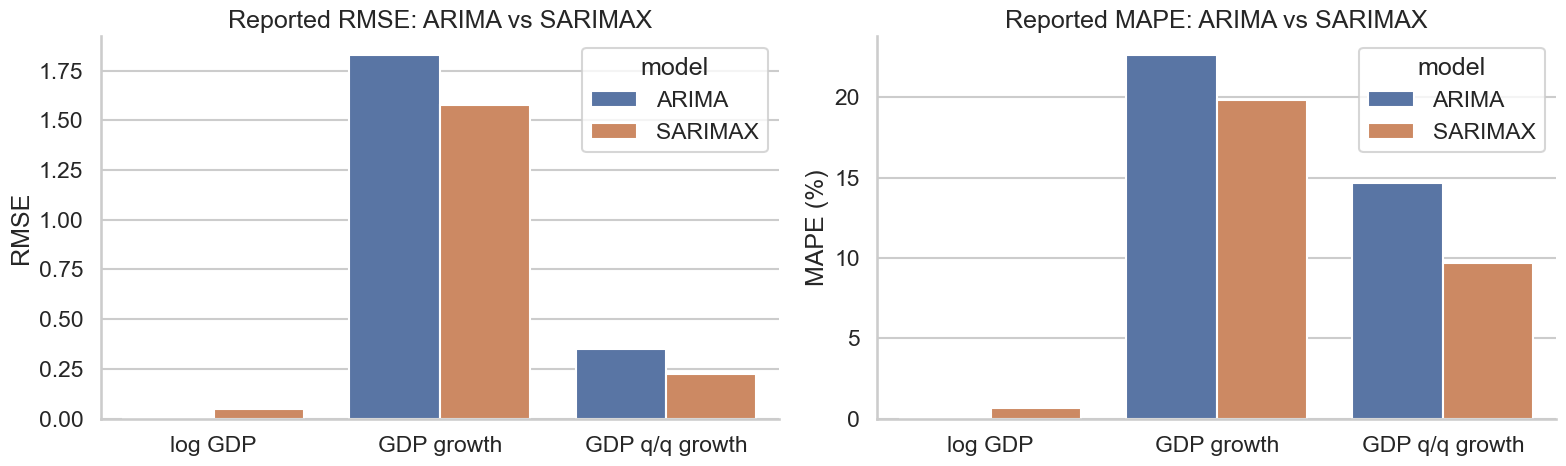

In [12]:
reported_forecast_results = pd.DataFrame(
    [
        ["log_gdp", "ARIMA", "(1, 1, 0)", 0.0080, 0.0074, 0.12],
        ["log_gdp", "SARIMAX", "(0, 2, 0)", 0.0463, 0.0392, 0.63],
        ["gdp_growth", "ARIMA", "(2, 0, 0)", 1.8303, 1.6438, 22.66],
        ["gdp_growth", "SARIMAX", "(2, 0, 0)", 1.5761, 1.4318, 19.86],
        ["gdp_qoq_pct_recalc", "ARIMA", "(1, 0, 0)", 0.3477, 0.3015, 14.64],
        ["gdp_qoq_pct_recalc", "SARIMAX", "(0, 0, 3)", 0.2232, 0.1933, 9.66],
    ],
    columns=["target", "model", "order", "RMSE", "MAE", "MAPE"],
)

pretty_target = {
    "log_gdp": "log GDP",
    "gdp_growth": "GDP growth",
    "gdp_qoq_pct_recalc": "GDP q/q growth",
}
reported_forecast_results["target_label"] = reported_forecast_results["target"].map(pretty_target)

display(reported_forecast_results)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(
    data=reported_forecast_results,
    x="target_label",
    y="RMSE",
    hue="model",
    ax=axes[0],
)
axes[0].set_title("Reported RMSE: ARIMA vs SARIMAX")
axes[0].set_xlabel("")
axes[0].set_ylabel("RMSE")

sns.barplot(
    data=reported_forecast_results,
    x="target_label",
    y="MAPE",
    hue="model",
    ax=axes[1],
)
axes[1].set_title("Reported MAPE: ARIMA vs SARIMAX")
axes[1].set_xlabel("")
axes[1].set_ylabel("MAPE (%)")

plt.tight_layout()
plt.show()


## Key takeaways for the written report

- The **time-series plots** provide the descriptive macro backdrop for the project.
- The **heatmap and scatter plots** help motivate the regression stage and show basic co-movement patterns.
- The **ACF/PACF figures** support the logic behind the ARIMA/SARIMAX modeling choices.
- The **SARIMAX forecast chart** is the clearest visual for the forecasting section because it shows train history, test observations, forecast path, and uncertainty bands in one figure.
- The **VAR IRFs** add a dynamic interpretation of macro shocks, especially for inflation and interest-rate disturbances.
- The **OLS/HAC coefficient plot** is one of the strongest visuals for the policy discussion because it directly shows sign, magnitude, and uncertainty for each macro driver.
- The **reported model-comparison chart** is a compact extra figure that makes the forecast-ranking result much easier to communicate in slides or the final report.

For the final written thesis, the most report-friendly figures are usually:
1. macro time-series panels,
2. the SARIMAX forecast chart,
3. the OLS coefficient chart,
4. the VAR IRF chart.
